In [90]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
from neurolib.models.rate_control import RateModel

import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Bistability

In [763]:
#aln = ALNModel()
aln = RateModel()

state_vars = aln.state_vars
init_vars = aln.init_vars

def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:1,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:1,i_time] = maxI_
    return control_

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
                    
rates_exc_init = np.array( [[0. * 0.01 * 0.5 ]] )
rates_inh_init = np.array( [[0. * 0.01 * 0.5 ]] )
mufe_init = np.array( [[0. * 3. * 0.5 ]] )  # mV/ms
mufi_init = np.array( [[0. * 3. * 0.5 ]] )  # mV/ms
IA_init = np.array( [[0. * 200. * 0.5 ]] )  # pA
seem_init = np.array( [[0. * 0.5 * 0.5 ]] )
seim_init = np.array( [[0. * 0.5 * 0.5 ]] )   
seev_init = np.array( [[0. * 0.01 * 0.5 ]] )
seiv_init = np.array( [[0. * 0.01 * 0.5 ]] )
siim_init = np.array( [[0. * 0.5 * 0.5 ]] )
siem_init = np.array( [[0. * 0.5 * 0.5 ]] )
siiv_init = np.array( [[0. * 0.01 * 0.5 ]] )
siev_init = np.array( [[0. * 0.01 * 0.5 ]] )
mue_ou = np.array( [[0. * 0.4]] ) #* np.ones((model.params.N,))
mui_ou = np.array( [[0. * 0.3]] ) #* np.ones((model.params.N,))

init_vars_zero = np.array( [rates_exc_init, 
                     rates_inh_init,
                     mufe_init,
                     mufi_init,
                     IA_init,
                     seem_init,
                     seim_init,
                     siem_init,
                     siim_init,
                     seev_init,
                     seiv_init,
                     siev_init,
                     siiv_init,
                     mue_ou,
                     mui_ou]
                    )
    
def setParametersALN(model):
    model.params.rates_exc_init = rates_exc_init
    model.params.rates_inh_init = rates_inh_init
    model.params.mufe_init = mufe_init
    model.params.mufi_init = mufi_init
    model.params.IA_init = IA_init
    model.params.seem_init = seem_init
    model.params.seim_init = seim_init
    model.params.seev_init = seev_init
    model.params.seiv_init = seiv_init
    model.params.siim_init = siim_init
    model.params.siem_init = siem_init
    model.params.siiv_init = siiv_init
    model.params.siev_init = siev_init
    model.params.mue_ou = mue_ou
    model.params.mui_ou = mui_ou

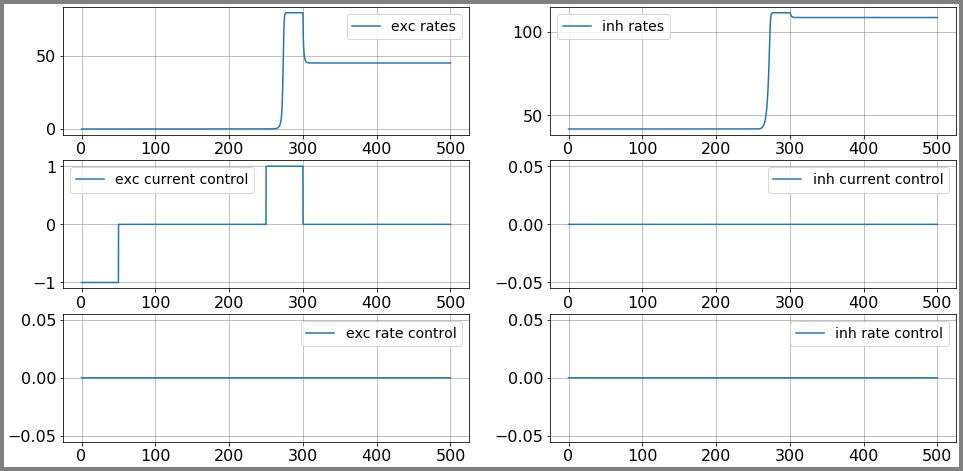

[ 45.19923743 108.58410102]


In [786]:
aln.params['duration'] = 500.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()

aln.params.ext_exc_current = 2.5
aln.params.ext_inh_current = 3.

aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

# NO ADAPTATION
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# NO DELAY
aln.params.de = 0.
aln.params.di = 0.

control0 = step_control(maxI_ = 1.)
plotFunc.plot_traces(aln, control0)
    
steady_rates = np.zeros((2))
steady_rates[0] = aln.rates_exc[0,-1] # high state exc
steady_rates[1] = aln.rates_inh[0,-1] # high state inh

print(steady_rates)

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-1]

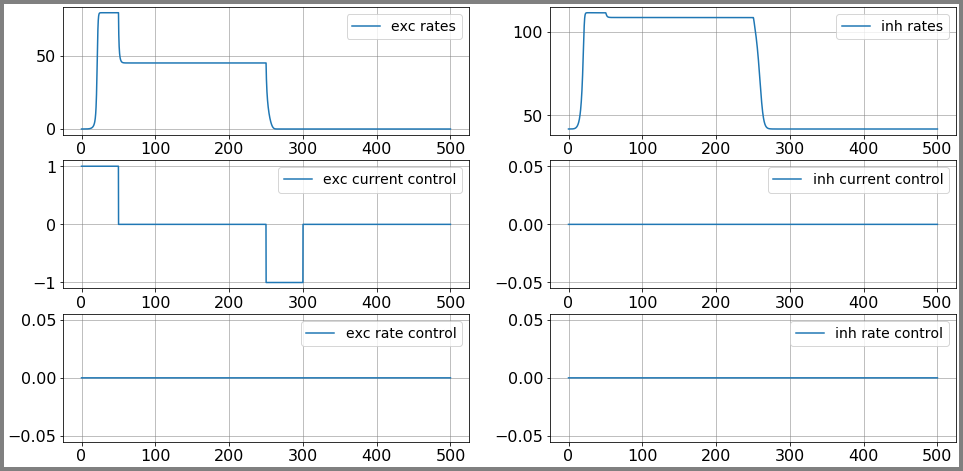

low state vars =  [ 4.47109264e-05  4.19187898e+01 -3.51148989e-01  1.47903349e+00
  0.00000000e+00  8.83019508e-06  8.63970226e-01  8.25284093e-06
  9.27431685e-01  5.45113479e-07  1.29595917e-03  4.76160642e-07
  8.67100700e-04  0.00000000e+00  0.00000000e+00  1.50618000e+00
  1.50055788e+00 -7.20279062e+01  1.62385826e+02  1.11179759e+01]


In [787]:
control0 = step_control(maxI_ = -1.)
plotFunc.plot_traces(aln, control0)

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    #print("final value of state var ", aln.state_vars[i], " : ", aln.state[state_vars[i]])
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-1]

print("low state vars = ", low_state_vars)

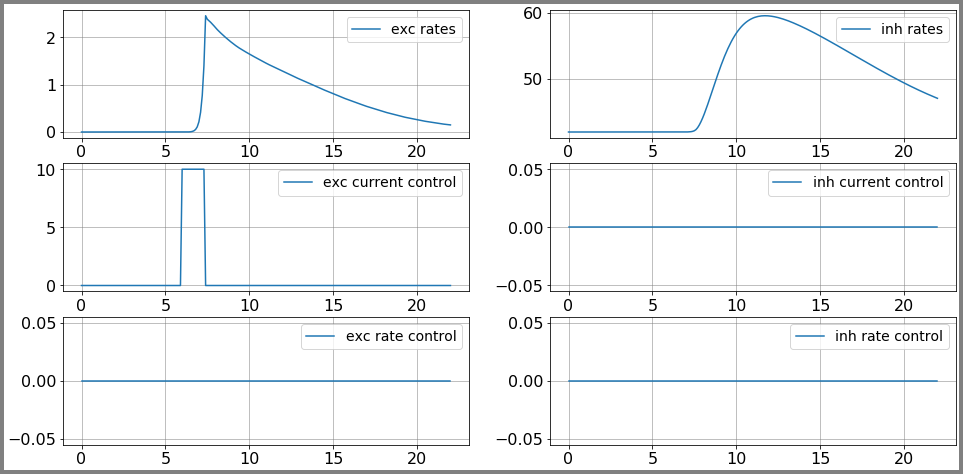

In [821]:
dur = 20
dur_pre = 2.
dur_post = 0.5
aln.params.duration = dur + dur_pre

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

setinit(low_state_vars)
control0 = aln.getZeroControl()
control0[0,0,60:74] += 10.
plotFunc.plot_traces(aln, control0)

# set high state rates as target
aln.params.duration = dur
target_lh = aln.getZeroTarget()
target_lh[:,0,:] = aln.rates_exc[0,n_pre-1:]
target_lh[:,1,:] = aln.rates_inh[0,n_pre-1:]

tol = 1e-12
start_step = 100.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

In [844]:
# A.1) low => high, current control, max current 1nA, precision only
case = "A1test"
cost.setParams(1.0, 0.0, 0.)
max_cntrl = 1e1 * 1. * 5.
min_cntrl = - max_cntrl
cntrl_vars = [0]
prec_vars = [0]

aln.params.duration = dur

max_it = 100

control0 = aln.getZeroControl()
control0[0,0,40:54] += 9.
control1 = bestControlA1[:,:,n_pre-1:-n_post+1]

setinit(low_state_vars)

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlA1, bestStateA1, costA1, runtimeA1, gradA1 = aln.A1(control0, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = False)

resultA1 = {"Opt_control": bestControlA1,
              "Opt_state": bestStateA1,
              "costArray": costA1,
              "runtimeArray": runtimeA1,    
}

dump_dicts = [opt_params, aln.params, resultA1]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  4.1772611386509775
RUN  1 , total integrated cost =  0.14631209444634252
RUN  2 , total integrated cost =  0.1281273517600156
RUN  3 , total integrated cost =  0.11805407644181926
RUN  4 , total integrated cost =  0.10123245235849856
RUN  5 , total integrated cost =  0.08983207681744279
RUN  6 , total integrated cost =  0.06617560890487842
RUN  7 , total integrated cost =  0.05396948863352413
RUN  8 , total integrated cost =  0.020414441085848025
RUN  9 , total integrated cost =  0.015614051440057234
RUN  10 , total integrated cost =  0.013767563560811292
RUN  11 , total integrated cost =  0.012019241012976611
RUN  12 , total integrated cost =  0.011484527104337781
RUN  13 , total integrated cost =  0.010909620021604522
RUN  14 , total integrated cost =  0.01051042910662306
RUN  15 , total integrated cost =  0.010100848995138688
RUN  16 , total integrated cost =  0.009774145522857226
RUN  17 , total integrated cost =  0.0094240316512589

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  100 , total integrated cost =  0.0005239731560116715
RUN  100 , total integrated cost =  0.0005239731560116715
Improved over  100  iterations by  99.98745653818088  percent.
Problem in initial value trasfer:  tau_exc 162.38270492510534 21.465336530774334
Problem in initial value trasfer:  tau_inh 11.117975875997336 1.3066430172804167
Problem in initial value trasfer:  Vmean_exc -63.213245114159285 -63.25129113032248
Problem in initial value trasfer:  tau_exc 45.80057281685917 18.5062194820662
Problem in initial value trasfer:  tau_inh 10.687497678810375 1.1326837158879566


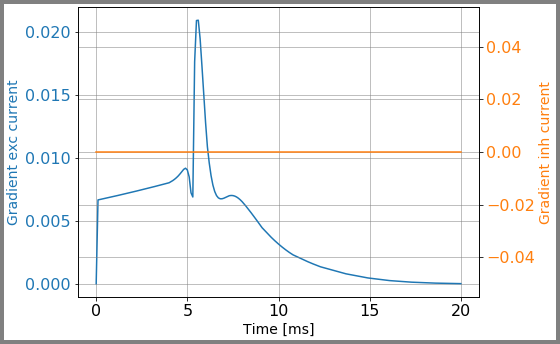

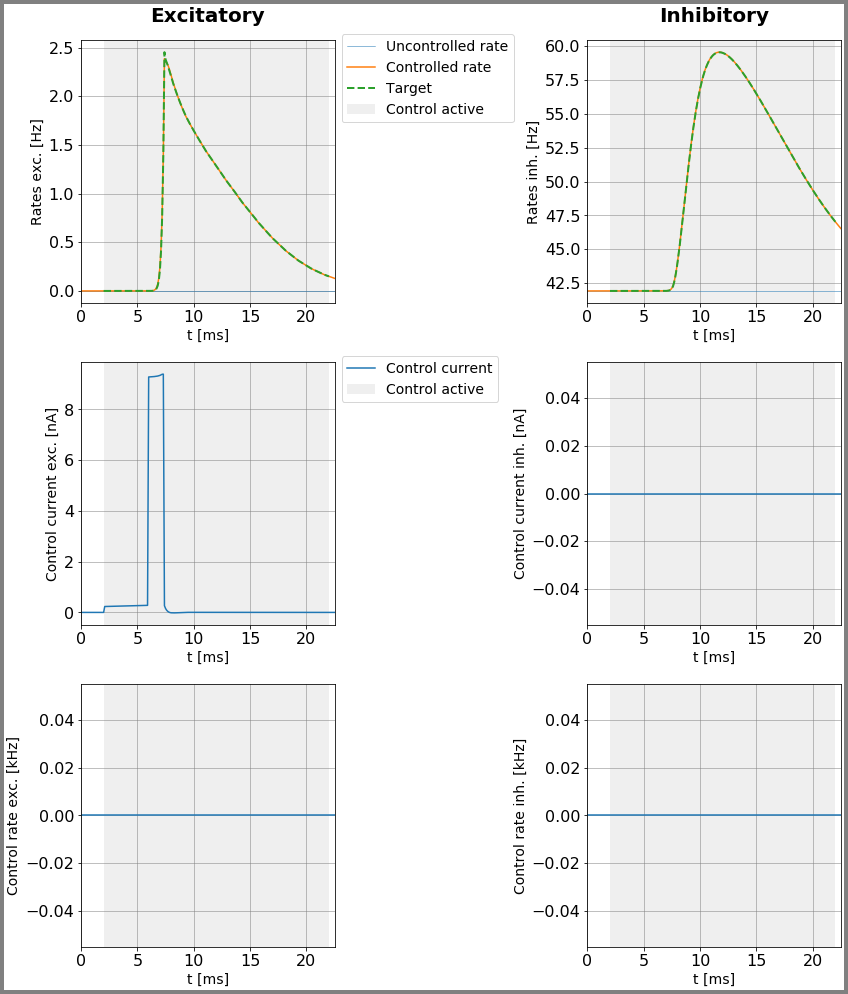

In [845]:
plotFunc.plot_gradient(gradA1, dur, aln.params.dt, path)

plotFunc.plot_control(aln, bestControlA1, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = case)

In [852]:
# A.2) low => high, max current 1nA, precision + energy + sparsity
case = "A2"
cost.setParams(1.0, .01, 0.)
max_cntrl = 1e3 * 1. * 5.
aln.params.duration = dur
cntrl_vars = [0]
prec_vars = [0]

start_step = 10.

max_it = 100

setinit(low_state_vars)
control0 = aln.getZeroControl()
control1 = bestControlA1[:,:,n_pre-1:-n_post+1]
control2 = bestControlA2[:,:,n_pre-1:-n_post+1]
#control3 = control2.copy()
#control3[0,0,:7] = 0.

# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlA2, bestStateA2, costA2, runtimeA2, gradA2 = aln.A1(control2, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars)

resultA2 = {"Opt_control": bestControlA2,
              "Opt_state": bestStateA2,
              "costArray": costA2,
              "runtimeArray": runtimeA2,    
}

dump_dicts = [opt_params, aln.params, resultA2]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )
# RUN  124 , total integrated cost =  4834.774392169099
# RUN  69 , total integrated cost =  4985.245413231114

#aln.params.duration = dur
#plotFunc.plot_traces(aln, bestControlA2[:,:,n_pre-1:-n_post+1])

set cost params
RUN  0 , total integrated cost =  0.26435722650877896
RUN  1 , total integrated cost =  0.2643478716439206
RUN  2 , total integrated cost =  0.26431906055962023
RUN  3 , total integrated cost =  0.26431171418766153
RUN  4 , total integrated cost =  0.2643084551379292
RUN  5 , total integrated cost =  0.2642803835952827
RUN  6 , total integrated cost =  0.2642744175390893
RUN  7 , total integrated cost =  0.26427408871625635
RUN  8 , total integrated cost =  0.2642737121017561
RUN  9 , total integrated cost =  0.2642690627172321
RUN  10 , total integrated cost =  0.2642524967273729
RUN  11 , total integrated cost =  0.2642513346367896
RUN  12 , total integrated cost =  0.264251291322262
RUN  13 , total integrated cost =  0.26425127878020244
RUN  14 , total integrated cost =  0.26425127605868204
RUN  15 , total integrated cost =  0.2642512753303322
RUN  16 , total integrated cost =  0.26425127511830804
RUN  17 , total integrated cost =  0.2642512750579191
RUN  18 , total 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  29 , total integrated cost =  0.2642512750321091
Improved over  29  iterations by  0.04007890310739981  percent.
Problem in initial value trasfer:  tau_exc 162.38270492510534 21.465336530774334
Problem in initial value trasfer:  tau_inh 11.117975875997336 1.3066430172804167
Problem in initial value trasfer:  Vmean_exc -63.228787710899645 -63.2667769251526
Problem in initial value trasfer:  tau_exc 45.89447139134804 18.519350367858287
Problem in initial value trasfer:  tau_inh 10.688167387845063 1.132888631719396


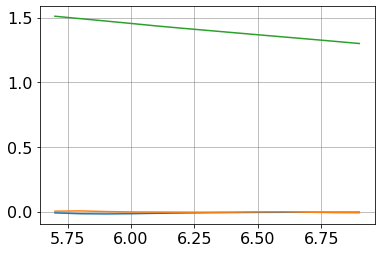

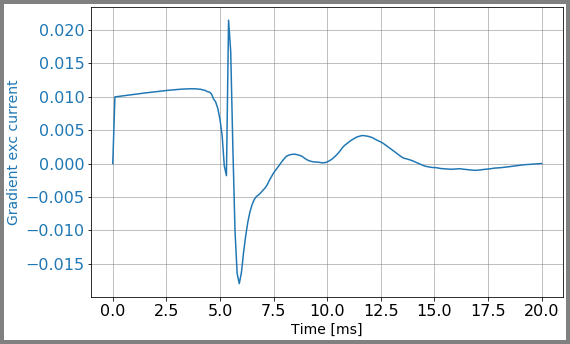

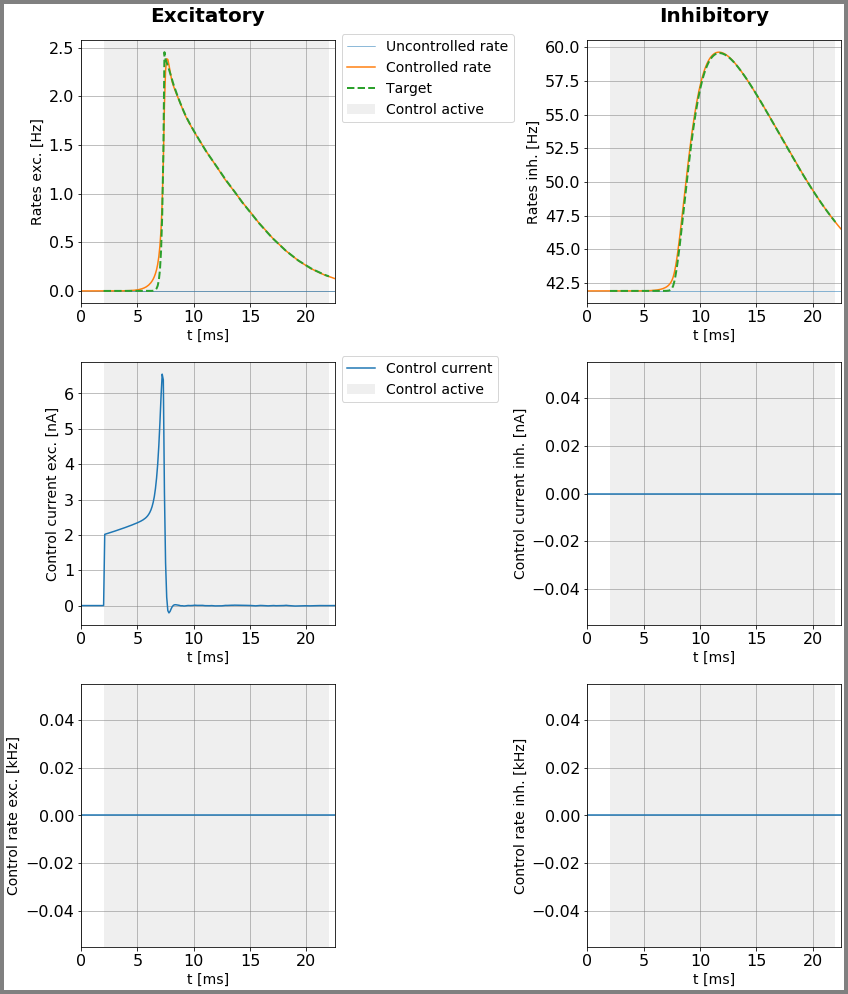

In [853]:
#diff = control1 - bestControlA2[:,:,n_pre-1:-n_pre+1]
#print("exc diff = ", diff[0,0,:])
#print("inh diff = ", diff[0,1,:])
t_zoom = np.arange(5.7,7,0.1)
plt.plot(t_zoom,gradA2[0,0,57:70])
plt.plot(t_zoom, bestControlA2[0,0,107:120])
plt.plot(t_zoom, bestStateA2[0,0,107:120])

plotFunc.plot_gradient(gradA2, dur, aln.params.dt, path, plot_vars = [0])

plotFunc.plot_control(aln, bestControlA2, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = case)

In [14]:
# A.3) low => high, rate control, max rate 100Hz, precision only
case = "A3"
cost.setParams(1.0, 0.0, 0.0)
max_cntrl = 0.1
cntrl_vars = [2]
aln.params.duration = dur

max_it = 5000

setinit(low_state_vars)
control0 = aln.getZeroControl()


# "HS", "FR", "PR", "HZ"
cgv = None

opt_params = {"max_it": max_it,
              "tol": tol,
              "start_step": start_step,
              "dur": dur,
              "dur_pre": dur_pre,
              "dur_post": dur_post,
              "cg_variant": cgv
}

bestControlA3, bestStateA3, costA3, runtimeA3, gradA3 = aln.A1(control0, target_lh, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars)

resultA3 = {"Opt_control": bestControlA3,
              "Opt_state": bestStateA3,
              "costArray": costA3,
              "runtimeArray": runtimeA3,    
}

dump_dicts = [opt_params, aln.params, resultA3]
filename = str(case + "_" + ".p")
pickle.dump( dump_dicts, open( filename, "wb" ) )

set cost params
RUN  0 , total integrated cost =  65195.87990054026
RUN  1 , total integrated cost =  39311.70594237719
RUN  2 , total integrated cost =  39254.96962439755
RUN  3 , total integrated cost =  39242.254302731846
RUN  4 , total integrated cost =  39237.944536518895
RUN  5 , total integrated cost =  39235.045637165014
RUN  6 , total integrated cost =  39234.13899423343
RUN  7 , total integrated cost =  39233.30089755711
RUN  8 , total integrated cost =  39232.835716694826
RUN  9 , total integrated cost =  39232.421632277175
RUN  10 , total integrated cost =  39232.162904681725
RUN  11 , total integrated cost =  39231.93395847
RUN  12 , total integrated cost =  39231.771586669754
RUN  13 , total integrated cost =  39231.62686848262
RUN  14 , total integrated cost =  39231.52239434578
RUN  15 , total integrated cost =  39231.429454870646
RUN  16 , total integrated cost =  39231.35963850149
RUN  17 , total integrated cost =  39231.29760109645
RUN  18 , total integrated cost =  

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  2978 , total integrated cost =  39230.85459651786
Improved over  2978  iterations by  39.82617512584141  percent.
Problem in initial value trasfer:  sigmae_f 1.5061818006347805 1.5061737188286086
Problem in initial value trasfer:  tau_exc 21.399339496785732 21.399385578873147
Problem in initial value trasfer:  Vmean_exc -56.695975267310494 -56.69624188543999


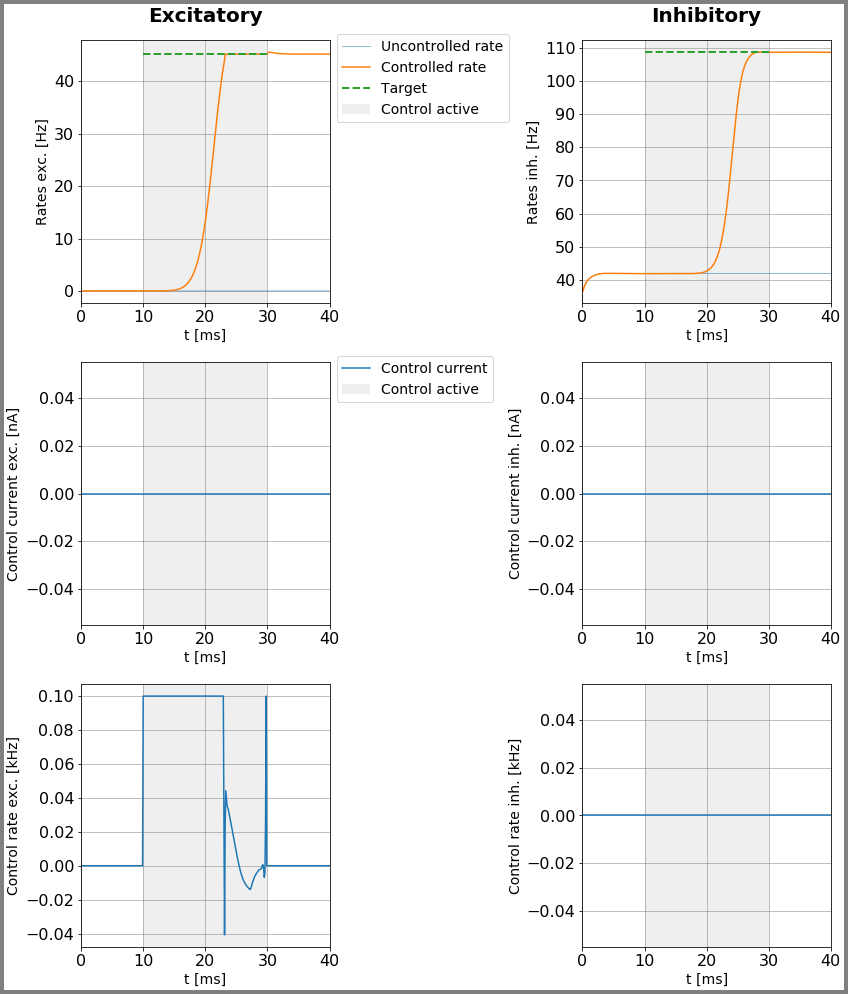

In [15]:
plotFunc.plot_control(aln, bestControlA3, dur, dur_pre, dur_post, low_state_vars, target_lh,
                      path, filename_ = case )

In [13]:
print(gradA3[:,:,-10:])

[[[ 0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
    0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
  [ 0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
    0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
  [-1.2956e-01 -1.2030e-01 -4.3945e-02  9.8129e-02  2.6006e-01
    3.5142e-01  2.7357e-01 -1.2107e-05 -5.8378e-05  0.0000e+00]
  [ 0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
    0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]]]
